# Process the AGAP airborne magnetic data

We try to recreate the BAS processing steps, as outlined here: https://data.bas.ac.uk/full-record.php?id=GB/NERC/BAS/PDC/01308

In [2]:
# %load_ext autoreload
# %autoreload 2

import cmocean
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import verde as vd

import airbornegeo

## Load data

This is a subset of the BAS AGAP survey over Antarctica's Gamburtsev Subglacial Mountains. The file is download and subset in the notebook `AGAP_magnetic_survey`.

In [31]:
data_df = pd.read_csv("data/AGAP_magnetic_survey.csv")

data_df = data_df[
    [
        "Lon",
        "Lat",
        "Height_WGS1984",
        "Date",
        "Time",
        "unixtime",
        "easting",
        "northing",
        "line_name",
        "line",
        "MagR",  # raw magnetic field intensity
        "MagC",  # compensated or low pass filtered (some dummies)
        "RefField",  # IGRF intensity
        # 'TCorr', # Tip tanks?
        "MagRTC",  # TFA
        "BCorr_AGAP_N",  # 60 min low pass filter magnetic base station
        "BCorr_AGAP_NS",
        "BCorr_AGAP_S",
        "BCorr_AGAP_SP",
        "BCorr_Applied",  # combined base stations
        "MagBRTC",  # MagRTC - Bcorr_Applied
        "ACorr",  # heading error correction
        "SCorr",  # ?
        "MagF",  # final TFA before levelling
        "MagL",  # cross-over levelled
        "MagML",  # microlevelled
    ]
]

print(data_df.columns)
data_df.head()

Index(['Lon', 'Lat', 'Height_WGS1984', 'Date', 'Time', 'unixtime', 'easting',
       'northing', 'line_name', 'line', 'MagR', 'MagC', 'RefField', 'MagRTC',
       'BCorr_AGAP_N', 'BCorr_AGAP_NS', 'BCorr_AGAP_S', 'BCorr_AGAP_SP',
       'BCorr_Applied', 'MagBRTC', 'ACorr', 'SCorr', 'MagF', 'MagL', 'MagML'],
      dtype='str')


,Lon,Lat,Height_WGS1984,Date,Time,unixtime,easting,northing,line_name,line,...,BCorr_AGAP_NS,BCorr_AGAP_S,BCorr_AGAP_SP,BCorr_Applied,MagBRTC,ACorr,SCorr,MagF,MagL,MagML
0,75.635600,-84.104393,4109.4,2008-12-17,0 days 07:53:42,1.229500e+09,621072.177354,159052.962392,DA500_11.0,1,...,NaN,NaN,18.04,-18.04,-8.00,8.32,-32.96,-32.96,-22.30,NaN
1,75.636138,-84.103897,4111.5,2008-12-17,0 days 07:53:43,1.229500e+09,621126.010622,159060.533993,DA500_11.0,1,...,NaN,NaN,18.01,-18.01,-8.82,7.47,-33.81,-33.81,-23.06,NaN
2,75.636699,-84.103403,4113.6,2008-12-17,0 days 07:53:44,1.229500e+09,621179.696916,159067.801202,DA500_11.0,1,...,NaN,NaN,17.98,-17.98,-9.66,6.60,-34.68,-34.68,-23.81,NaN
3,75.637282,-84.102910,4115.4,2008-12-17,0 days 07:53:45,1.229500e+09,621233.338990,159074.801823,DA500_11.0,1,...,NaN,NaN,17.95,-17.95,-10.51,5.72,-35.56,-35.56,-24.57,NaN
4,75.637876,-84.102417,4117.1,2008-12-17,0 days 07:53:46,1.229500e+09,621287.011834,159081.682095,DA500_11.0,1,...,NaN,NaN,17.92,-17.92,-11.36,4.84,-36.44,-36.44,-25.32,NaN


In [22]:
# # turn to geopandas geodataframe
# data_df = gpd.GeoDataFrame(
#     data_df,
#     geometry=gpd.points_from_xy(x=data_df.easting, y=data_df.northing),
#     crs="EPSG:3031",
# )

## Distance along line

In [32]:
data_df["distance_along_line"] = airbornegeo.along_track_distance(
    data_df,
    groupby_column="line",
)
data_df.head()

,Lon,Lat,Height_WGS1984,Date,Time,unixtime,easting,northing,line_name,line,...,BCorr_AGAP_S,BCorr_AGAP_SP,BCorr_Applied,MagBRTC,ACorr,SCorr,MagF,MagL,MagML,distance_along_line
0,75.635600,-84.104393,4109.4,2008-12-17,0 days 07:53:42,1.229500e+09,621072.177354,159052.962392,DA500_11.0,1,...,NaN,18.04,-18.04,-8.00,8.32,-32.96,-32.96,-22.30,NaN,0.000000
1,75.636138,-84.103897,4111.5,2008-12-17,0 days 07:53:43,1.229500e+09,621126.010622,159060.533993,DA500_11.0,1,...,NaN,18.01,-18.01,-8.82,7.47,-33.81,-33.81,-23.06,NaN,54.363130
2,75.636699,-84.103403,4113.6,2008-12-17,0 days 07:53:44,1.229500e+09,621179.696916,159067.801202,DA500_11.0,1,...,NaN,17.98,-17.98,-9.66,6.60,-34.68,-34.68,-23.81,NaN,108.539052
3,75.637282,-84.102910,4115.4,2008-12-17,0 days 07:53:45,1.229500e+09,621233.338990,159074.801823,DA500_11.0,1,...,NaN,17.95,-17.95,-10.51,5.72,-35.56,-35.56,-24.57,NaN,162.636009
4,75.637876,-84.102417,4117.1,2008-12-17,0 days 07:53:46,1.229500e+09,621287.011834,159081.682095,DA500_11.0,1,...,NaN,17.92,-17.92,-11.36,4.84,-36.44,-36.44,-25.32,NaN,216.748044


In [33]:
data_df[data_df.distance_along_line == 0]

,Lon,Lat,Height_WGS1984,Date,Time,unixtime,easting,northing,line_name,line,...,BCorr_AGAP_S,BCorr_AGAP_SP,BCorr_Applied,MagBRTC,ACorr,SCorr,MagF,MagL,MagML,distance_along_line
0,75.635600,-84.104393,4109.4,2008-12-17,0 days 07:53:42,1.229500e+09,6.210722e+05,159052.962392,DA500_11.0,1,...,NaN,18.04,-18.04,-8.00,8.32,-32.96,-32.96,-22.30,NaN,0.0
12549,80.056823,-84.284715,3760.2,2009-01-02,0 days 09:45:44.290000,1.230890e+09,6.121394e+05,107310.839116,DA600_17.0,2,...,-4.2,NaN,5.10,92.49,0.49,NaN,92.98,49.88,47.76,0.0
12550,80.056823,-84.284715,3760.2,2009-01-02,0 days 09:45:45.290000,1.230890e+09,6.121394e+05,107310.839116,DA600_17.0,2,...,-4.2,NaN,5.01,91.16,1.21,NaN,92.37,49.09,47.11,0.0
12551,80.056823,-84.284715,3760.2,2009-01-02,0 days 09:45:46.290000,1.230890e+09,6.121394e+05,107310.839116,DA600_17.0,2,...,-4.2,NaN,5.00,89.93,1.74,NaN,91.68,48.38,46.45,0.0
12552,80.056823,-84.284715,3760.2,2009-01-02,0 days 09:45:47.290000,1.230890e+09,6.121394e+05,107310.839116,DA600_17.0,2,...,-4.2,NaN,5.00,89.18,1.80,NaN,90.98,47.68,45.79,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1057949,93.229253,-79.772312,4020.5,2009-01-06,0 days 12:59:27.440000,1.231247e+09,1.112335e+06,-62758.899078,VR10230_26.0,206,...,-1.6,NaN,23.53,-14.92,0.02,NaN,-14.90,-19.50,NaN,0.0
1057950,93.229253,-79.772312,4020.5,2009-01-06,0 days 12:59:28.440000,1.231247e+09,1.112335e+06,-62758.899078,VR10230_26.0,206,...,-1.6,NaN,23.57,-15.00,0.10,NaN,-14.90,-19.50,NaN,0.0
1057951,93.229253,-79.772312,4020.5,2009-01-06,0 days 12:59:29.440000,1.231247e+09,1.112335e+06,-62758.899078,VR10230_26.0,206,...,-1.6,NaN,23.60,-15.00,0.10,NaN,-14.90,-19.50,NaN,0.0
1057952,93.229253,-79.772312,4020.5,2009-01-06,0 days 12:59:30.440000,1.231247e+09,1.112335e+06,-62758.899078,VR10230_26.0,206,...,-1.6,NaN,23.53,-15.07,0.17,NaN,-14.90,-19.50,NaN,0.0


In [34]:
# Some lines have many rows all at a distance of 0, meaning the plane was stationary, remove all of these.
data_df = data_df.drop_duplicates(subset=["line", "distance_along_line"], keep="last")
data_df[data_df.distance_along_line == 0]

,Lon,Lat,Height_WGS1984,Date,Time,unixtime,easting,northing,line_name,line,...,BCorr_AGAP_S,BCorr_AGAP_SP,BCorr_Applied,MagBRTC,ACorr,SCorr,MagF,MagL,MagML,distance_along_line
0,75.635600,-84.104393,4109.4,2008-12-17,0 days 07:53:42,1.229500e+09,6.210722e+05,159052.962392,DA500_11.0,1,...,NaN,18.04,-18.04,-8.00,8.32,-32.96,-32.96,-22.30,NaN,0.0
12581,80.056823,-84.284715,3760.2,2009-01-02,0 days 09:46:16.290000,1.230890e+09,6.121394e+05,107310.839116,DA600_17.0,2,...,-4.30,NaN,5.29,64.89,0.42,NaN,65.31,21.02,21.50,0.0
22318,81.044396,-77.616548,3570.5,2009-01-02,0 days 15:48:55.290000,1.230911e+09,1.334079e+06,210237.785598,DA650_18.0,3,...,-98.86,NaN,120.40,-86.25,-0.78,NaN,-87.03,-64.33,-56.67,0.0
33743,83.114914,-84.234735,3767.8,2009-01-05,0 days 20:12:24.150000,1.231186e+09,6.223969e+05,75153.918551,DA670_24.0,4,...,-94.50,NaN,93.50,129.96,2.77,NaN,132.73,96.73,99.97,0.0
43846,82.512819,-77.650232,3637.8,2009-01-06,0 days 16:44:02.440000,1.231260e+09,1.335359e+06,175499.361474,DA720_27.0,5,...,-132.20,NaN,78.30,47.01,-2.89,NaN,44.13,57.93,58.49,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1041888,108.279245,-81.454493,3637.6,2008-12-26,0 days 23:16:19,1.230333e+09,8.832097e+05,-291738.794000,VR10150_7.0,202,...,-25.90,NaN,17.90,-55.08,0.00,NaN,-55.08,-39.98,NaN,0.0
1047806,85.073204,-81.801844,4131.6,2009-01-05,0 days 12:09:01.150000,1.231157e+09,8.889145e+05,76625.657672,VR10170_23.0,203,...,-20.00,NaN,39.56,-140.49,-0.24,NaN,-140.72,-121.89,NaN,0.0
1051234,99.820535,-80.709317,3913.4,2009-01-05,0 days 13:20:43.150000,1.231162e+09,9.967607e+05,-172538.400163,VR10190_23.0,204,...,-19.60,NaN,23.80,-156.44,-0.07,NaN,-156.51,-164.13,NaN,0.0
1055368,84.377500,-80.609123,4227.9,2009-01-06,0 days 12:01:52.440000,1.231243e+09,1.017620e+06,100182.015913,VR10210_26.0,205,...,-28.60,NaN,27.16,2.14,0.00,NaN,2.14,-28.86,NaN,0.0


## IGRF correction

Number of segments: 13


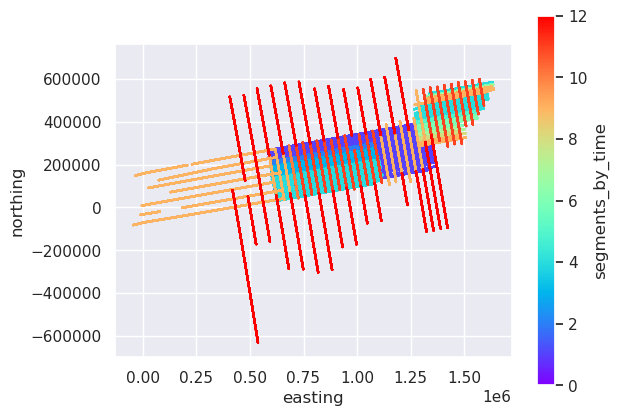

In [35]:
# make a datetime column
data_df["datetime"] = data_df.Date + " " + data_df.Time.str.split("days ").str.get(1)

# make segments where there are > 6 hr gaps in time
data_df["segments_by_time"] = airbornegeo.split_into_segments(
    data_df,
    column_name="unixtime",
    threshold=60 * 60 * 60 * 6,  # 6 hrs
)
print(f"Number of segments: {len(data_df.segments_by_time.unique())}")

ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="segments_by_time",
    s=0.2,
    cmap="rainbow",
)
ax.set_aspect("equal")

In [36]:
intensity, inc, dec = airbornegeo.igrf(
    data_df,
    datetime_column="datetime",
    latitude_column="Lat",
    longitude_column="Lon",
    height_column="Height_WGS1984",
    groupby_column="segments_by_time",
)
data_df["IGRF_intensity"] = intensity

data_df["mag_IGRF_corrected"] = data_df.MagC - data_df.IGRF_intensity

data_df.head()

Segments:   0%|          | 0/13 [00:00<?, ?it/s]

,Lon,Lat,Height_WGS1984,Date,Time,unixtime,easting,northing,line_name,line,...,ACorr,SCorr,MagF,MagL,MagML,distance_along_line,datetime,segments_by_time,IGRF_intensity,mag_IGRF_corrected
0,75.635600,-84.104393,4109.4,2008-12-17,0 days 07:53:42,1.229500e+09,621072.177354,159052.962392,DA500_11.0,1,...,8.32,-32.96,-32.96,-22.30,NaN,0.000000,2008-12-17 07:53:42,0,55085.052201,58.047799
1,75.636138,-84.103897,4111.5,2008-12-17,0 days 07:53:43,1.229500e+09,621126.010622,159060.533993,DA500_11.0,1,...,7.47,-33.81,-33.81,-23.06,NaN,54.363130,2008-12-17 07:53:43,0,55085.014585,57.185415
2,75.636699,-84.103403,4113.6,2008-12-17,0 days 07:53:44,1.229500e+09,621179.696916,159067.801202,DA500_11.0,1,...,6.60,-34.68,-34.68,-23.81,NaN,108.539052,2008-12-17 07:53:44,0,55084.979022,56.320978
3,75.637282,-84.102910,4115.4,2008-12-17,0 days 07:53:45,1.229500e+09,621233.338990,159074.801823,DA500_11.0,1,...,5.72,-35.56,-35.56,-24.57,NaN,162.636009,2008-12-17 07:53:45,0,55084.953265,55.436735
4,75.637876,-84.102417,4117.1,2008-12-17,0 days 07:53:46,1.229500e+09,621287.011834,159081.682095,DA500_11.0,1,...,4.84,-36.44,-36.44,-25.32,NaN,216.748044,2008-12-17 07:53:46,0,55084.931072,54.548928


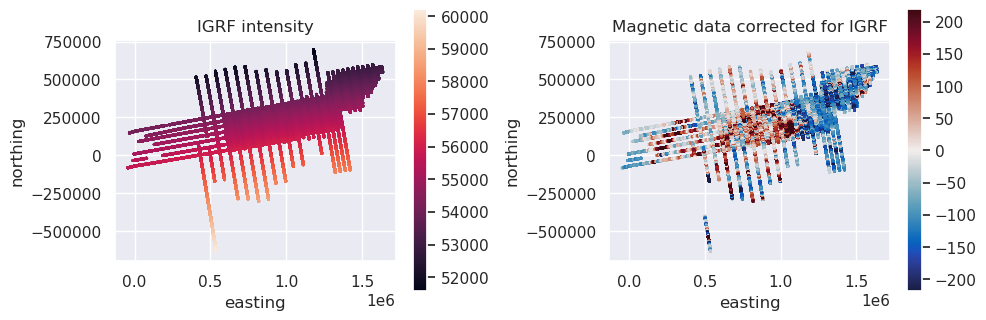

In [37]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6))

ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="IGRF_intensity",
    s=1,
    ax=axs[0],
    colorbar=False,
    title="IGRF intensity",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

maxabs = vd.maxabs(data_df.mag_IGRF_corrected, percentile=95)
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="mag_IGRF_corrected",
    s=1,
    cmap=cmocean.cm.balance,
    vmin=-maxabs,
    vmax=maxabs,
    ax=axs[1],
    colorbar=False,
    title="Magnetic data corrected for IGRF",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

plt.tight_layout()
plt.show()

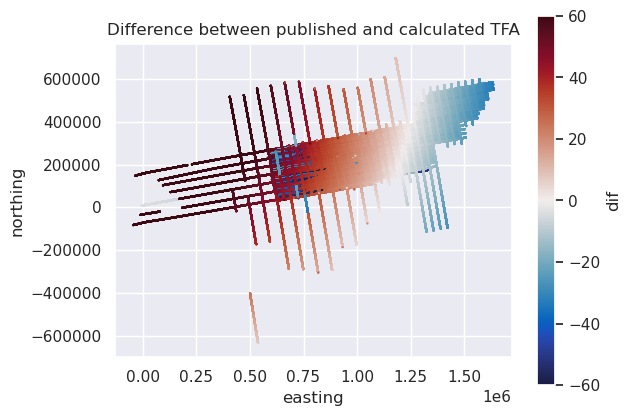

In [38]:
# compare the published TFA with the one calculated here
data_df["dif"] = data_df.mag_IGRF_corrected - data_df.MagRTC

maxabs = vd.maxabs(data_df.dif, percentile=95)
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="dif",
    cmap=cmocean.cm.balance,
    vmin=-maxabs,
    vmax=maxabs,
    s=0.2,
    title="Difference between published and calculated TFA",
)
ax.set_aspect("equal")

In [39]:
# for now just use their values
data_df = data_df.drop(columns=["mag_IGRF_corrected"], errors="ignore")
data_df["mag_IGRF_corrected"] = data_df.MagRTC

## Diurnal correction

In [40]:
data_df["mag_diurnal_corrected"] = data_df.mag_IGRF_corrected - data_df.BCorr_Applied
data_df.head()

,Lon,Lat,Height_WGS1984,Date,Time,unixtime,easting,northing,line_name,line,...,MagF,MagL,MagML,distance_along_line,datetime,segments_by_time,IGRF_intensity,dif,mag_IGRF_corrected,mag_diurnal_corrected
0,75.635600,-84.104393,4109.4,2008-12-17,0 days 07:53:42,1.229500e+09,621072.177354,159052.962392,DA500_11.0,1,...,-32.96,-22.30,NaN,0.000000,2008-12-17 07:53:42,0,55085.052201,48.007799,10.04,28.08
1,75.636138,-84.103897,4111.5,2008-12-17,0 days 07:53:43,1.229500e+09,621126.010622,159060.533993,DA500_11.0,1,...,-33.81,-23.06,NaN,54.363130,2008-12-17 07:53:43,0,55085.014585,47.995415,9.19,27.20
2,75.636699,-84.103403,4113.6,2008-12-17,0 days 07:53:44,1.229500e+09,621179.696916,159067.801202,DA500_11.0,1,...,-34.68,-23.81,NaN,108.539052,2008-12-17 07:53:44,0,55084.979022,48.000978,8.32,26.30
3,75.637282,-84.102910,4115.4,2008-12-17,0 days 07:53:45,1.229500e+09,621233.338990,159074.801823,DA500_11.0,1,...,-35.56,-24.57,NaN,162.636009,2008-12-17 07:53:45,0,55084.953265,47.996735,7.44,25.39
4,75.637876,-84.102417,4117.1,2008-12-17,0 days 07:53:46,1.229500e+09,621287.011834,159081.682095,DA500_11.0,1,...,-36.44,-25.32,NaN,216.748044,2008-12-17 07:53:46,0,55084.931072,47.988928,6.56,24.48


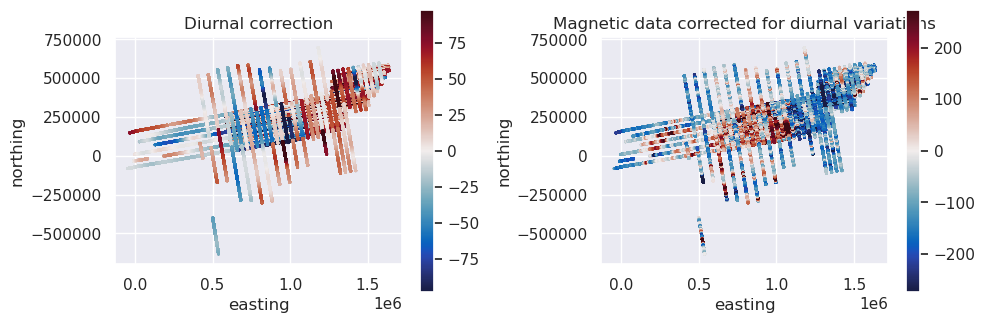

In [41]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6))

maxabs = vd.maxabs(data_df.BCorr_Applied, percentile=95)
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="BCorr_Applied",
    s=1,
    ax=axs[0],
    colorbar=False,
    cmap=cmocean.cm.balance,
    vmin=-maxabs,
    vmax=maxabs,
    title="Diurnal correction",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

maxabs = vd.maxabs(data_df.mag_diurnal_corrected, percentile=95)
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="mag_diurnal_corrected",
    s=1,
    cmap=cmocean.cm.balance,
    vmin=-maxabs,
    vmax=maxabs,
    ax=axs[1],
    colorbar=False,
    title="Magnetic data corrected for diurnal variations",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.5)

plt.tight_layout()
plt.show()

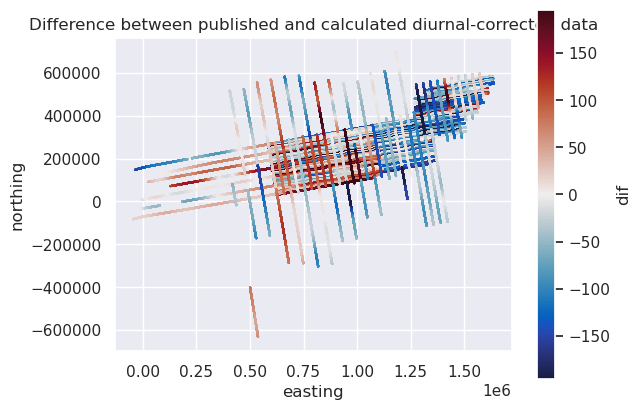

In [42]:
# compare the published TFA with the one calculated here
data_df["dif"] = data_df.mag_diurnal_corrected - data_df.MagBRTC

maxabs = vd.maxabs(data_df.dif, percentile=95)
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="dif",
    cmap=cmocean.cm.balance,
    vmin=-maxabs,
    vmax=maxabs,
    s=0.2,
    title="Difference between published and calculated diurnal-corrected data",
)
ax.set_aspect("equal")

In [43]:
# for now just use their values
data_df = data_df.drop(columns=["mag_diurnal_corrected"], errors="ignore")
data_df["mag_diurnal_corrected"] = data_df.MagBRTC

## Final data

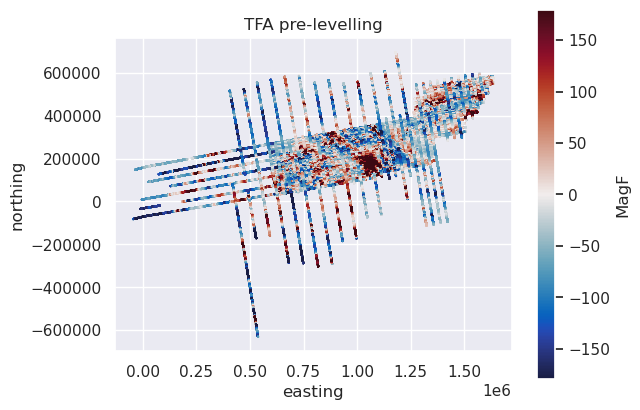

In [44]:
maxabs = vd.maxabs(data_df.MagF, percentile=95)
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="MagF",
    cmap=cmocean.cm.balance,
    vmin=-maxabs,
    vmax=maxabs,
    s=0.2,
    title="TFA pre-levelling",
)
ax.set_aspect("equal")

## Save csv

In [45]:
# save to csv for further levelling notebook
# eventually will use our version, but for checking the levelling is working correctly,
# we will just use their version
df = data_df

df = df[
    [
        "line",
        "easting",
        "northing",
        "Lon",
        "Lat",
        "Height_WGS1984",
        "unixtime",
        "distance_along_line",
        "MagF",
        "MagL",
        "MagML",
    ]
]

df = df.rename(
    columns={
        "MagF": "mag",
        "MagL": "mag_levelled",
        "MagML": "mag_microlevelled",
        "Lon": "longitude",
        "Lat": "latitude",
        "Height_WGS1984": "height",
    }
)
df = df.reset_index(drop=True)

df

,line,easting,northing,longitude,latitude,height,unixtime,distance_along_line,mag,mag_levelled,mag_microlevelled
0,1,6.210722e+05,159052.962392,75.635600,-84.104393,4109.4,1.229500e+09,0.000000,-32.96,-22.30,NaN
1,1,6.211260e+05,159060.533993,75.636138,-84.103897,4111.5,1.229500e+09,54.363130,-33.81,-23.06,NaN
2,1,6.211797e+05,159067.801202,75.636699,-84.103403,4113.6,1.229500e+09,108.539052,-34.68,-23.81,NaN
3,1,6.212333e+05,159074.801823,75.637282,-84.102910,4115.4,1.229500e+09,162.636009,-35.56,-24.57,NaN
4,1,6.212870e+05,159081.682095,75.637876,-84.102417,4117.1,1.229500e+09,216.748044,-36.44,-25.32,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1050320,206,1.082077e+06,112797.936801,84.048866,-80.011318,4191.9,1.231249e+09,178164.532974,-29.86,-34.44,NaN
1050321,206,1.082065e+06,112872.636385,84.044883,-80.011364,4192.3,1.231249e+09,178240.329983,-30.84,-35.36,NaN
1050322,206,1.082052e+06,112947.255346,84.040903,-80.011412,4192.9,1.231249e+09,178316.084662,-31.76,-36.26,NaN
1050323,206,1.082043e+06,112994.267330,84.038395,-80.011443,4193.3,1.231249e+09,178363.827125,-32.59,-37.16,NaN


In [46]:
df.to_csv("data/AGAP_magnetic_survey_processed.csv", index=False)

In [47]:
airbornegeo.plotly_points(
    df[::10],
    color_col="mag_microlevelled",
    size=3,
)

In [48]:
airbornegeo.plotly_points(
    df[::10],
    color_col="mag_levelled",
    size=3,
)

In [49]:
# block reduce by line to speed up the notebook
df_blocked = airbornegeo.block_reduce(
    df,
    np.median,
    spacing=200,
    reduce_by="distance_along_line",
    groupby_column="line",
)
df_blocked

Block-reducing segments:   0%|          | 0/206 [00:00<?, ?it/s]

,distance_along_line,tmp,line,easting,northing,longitude,latitude,height,unixtime,mag,mag_levelled,mag_microlevelled
0,81.451091,0.0,1,6.211529e+05,159064.167598,75.636418,-84.103650,4112.55,1.229500e+09,-34.245,-23.435,NaN
1,297.742539,0.0,1,6.213673e+05,159092.051982,75.638758,-84.101679,4119.45,1.229500e+09,-37.740,-26.450,NaN
2,512.819231,0.0,1,6.215803e+05,159122.206492,75.640867,-84.099716,4124.15,1.229500e+09,-40.975,-29.410,NaN
3,700.811387,0.0,1,6.217661e+05,159150.747140,75.642512,-84.097999,4127.50,1.229500e+09,-43.430,-31.940,NaN
4,861.711758,0.0,1,6.219250e+05,159176.326498,75.643816,-84.096528,4131.00,1.229500e+09,-45.300,-34.060,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
352090,177481.910664,0.0,206,1.082191e+06,112124.803785,84.084743,-80.010923,4191.10,1.231249e+09,-20.910,-25.410,NaN
352091,177671.458931,0.0,206,1.082160e+06,112311.745703,84.074781,-80.011032,4191.35,1.231249e+09,-23.525,-28.040,NaN
352092,177861.049986,0.0,206,1.082128e+06,112498.706874,84.064816,-80.011141,4191.50,1.231249e+09,-26.040,-30.540,NaN
352093,178088.659832,0.0,206,1.082090e+06,112723.160432,84.052853,-80.011272,4191.70,1.231249e+09,-28.960,-33.460,NaN


In [50]:
df_blocked.to_csv("data/AGAP_magnetic_survey_processed_blocked.csv", index=False)